# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** _(sinya kumari)_

**Roll Number:** _(023-24-0227)_

**GitHub Repository:** _(https://github.com/sinyaakumarii/lab2_sinya_churn_.git)_

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [5]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("D:/ML/lab2_sinya_churn/Telco-Customer-Churn.csv")


---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
_(Telecom is losing customers to competitors. Need to predict who's likely to leave (churn) so the company can intervene early. Target variable: likely a binary Churn (Yes/No) column)_

**Answer 2:**
_(Tenure — newer customers churn more Monthly/Total charges — price sensitivity drives switching Contract type — month-to-month = easy to leave, no lock-in Customer service calls — complaints signal dissatisfaction Internet service type / add-ons — service quality & "stickiness" Customer ID — a unique identifier with no predictive meaning, just a row label.
Gender — in most telecom churn datasets, gender shows negligible correlation with churn; it's demographic noise rather than a behavioral driver.)_

**Answer 3:**
_(Does churn cluster in early tenure or a specific contract type?
Do support calls spike right before someone churns — is there a warning threshold?)_

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [6]:
# Task 4 — dataset shape, column names, data types
df.shape
df.dtypes
df.info()




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
# Task 5 — identify identifier columns / wrong data types

print("Identifier Column: 'customerID' - It is a unique label per row and has no predictive value.")
print("Wrong Data Type: 'TotalCharges' - It is loaded as an 'object' (string) but should be a numeric (float) type.")


Identifier Column: 'customerID' - It is a unique label per row and has no predictive value.
Wrong Data Type: 'TotalCharges' - It is loaded as an 'object' (string) but should be a numeric (float) type.


In [9]:
# Task 6 — unique values in 3 categorical columns

categorical_cols = ['Contract', 'PaymentMethod', 'InternetService']

for col in categorical_cols:
    print(f"--- {col} ---")
    print(df[col].unique())
    print(f"Number of unique values: {df[col].nunique()}\n")

--- Contract ---
['Month-to-month' 'One year' 'Two year']
Number of unique values: 3

--- PaymentMethod ---
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Number of unique values: 4

--- InternetService ---
['DSL' 'Fiber optic' 'No']
Number of unique values: 3



**Observations (Part 2):**
_(summarize what you found — numerical features, categorical features, suspicious columns, etc.)_

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [10]:
# Task 7 — missing values: count and percentage per column
missing_counts = df.isnull().sum()
missing_percentages = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({'Missing Count': missing_counts, 'Percentage (%)': missing_percentages})
print(missing_summary)

                  Missing Count  Percentage (%)
customerID                    0             0.0
gender                        0             0.0
SeniorCitizen                 0             0.0
Partner                       0             0.0
Dependents                    0             0.0
tenure                        0             0.0
PhoneService                  0             0.0
MultipleLines                 0             0.0
InternetService               0             0.0
OnlineSecurity                0             0.0
OnlineBackup                  0             0.0
DeviceProtection              0             0.0
TechSupport                   0             0.0
StreamingTV                   0             0.0
StreamingMovies               0             0.0
Contract                      0             0.0
PaperlessBilling              0             0.0
PaymentMethod                 0             0.0
MonthlyCharges                0             0.0
TotalCharges                  0         

In [11]:
# Task 8 — duplicate rows vs duplicate IDs
duplicate_rows = df.duplicated().sum()
duplicate_ids = df['customerID'].duplicated().sum()

print(f"Total duplicate rows: {duplicate_rows}")
print(f"Total duplicate customer IDs: {duplicate_ids}")


Total duplicate rows: 0
Total duplicate customer IDs: 0


In [12]:
# Task 9 — investigate a suspicious / invalid value
blank_charges = df[df['TotalCharges'] == " "]
print(f"Number of rows with empty spaces in TotalCharges: {len(blank_charges)}")


Number of rows with empty spaces in TotalCharges: 11


**Answer 7 (which missing-value problems need action, and why):**
_(t first glance, the code output shows exactly 0 missing values across all columns. However, this is deceptive! Because TotalCharges is currently stored as text (an object), standard missing value functions like isnull() don't detect its hidden missing data. We must take action on these hidden missing values once we locate them, otherwise, our numerical calculations and future machine learning models will crash.)_

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
_(Both are 0, but they are different issues. A duplicate row means an identical data entry error occurred. A duplicate ID means a single customer appears in multiple rows, potentially with different contract or billing data.)_

**Answer 9 (suspicious value found and how):**
_(The TotalCharges column contains 11 empty spaces (" ") instead of numeric values or standard NaNs. I found this by investigating why pandas loaded a financial column as a text object instead of a float.)_

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|-customerID is a non-predictive identifier-|-remove column-|-df.drop(columns=['customerID'])-|-Has no value for machine learning and can cause overfitting.-|
| _e.g. TotalCharges stored as text_ | _Convert to float_ | _pd.to_numeric(..., errors='coerce')_ | _Total charges are numerical values needed for math/modeling._ |
| _TotalCharges contains 11 blank spaces (" ")_ | _drop the rows_ | _df.dropna(subset=['TotalCharges'])_ | _11 rows is a negligible loss (<0.2% of data); dropping is safest._ |


In [13]:
# Task 11 — apply your cleaning decisions here
clean_df = df.copy()

# 1. Drop customerID
clean_df = clean_df.drop(columns=['customerID'])

# 2 & 3. Convert TotalCharges to numeric and drop the newly created NaNs
clean_df['TotalCharges'] = pd.to_numeric(clean_df['TotalCharges'], errors='coerce')
clean_df = clean_df.dropna(subset=['TotalCharges'])

In [14]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)
print(clean_df.info())
print(f"\nMissing TotalCharges: {clean_df['TotalCharges'].isnull().sum()}")


<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

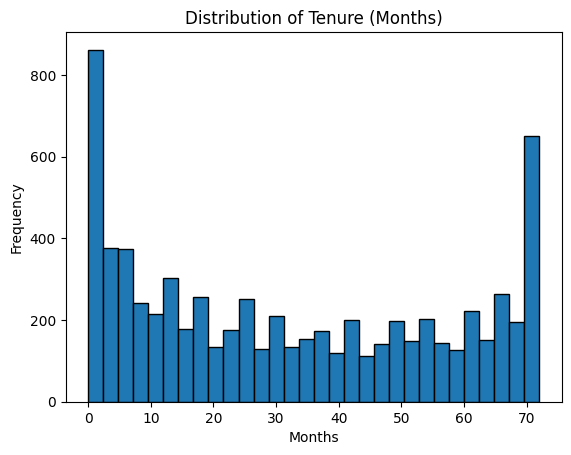

In [15]:
# Task 12 — numerical feature 1: distribution plot
df['tenure'].plot(kind='hist', bins=30, title='Distribution of Tenure (Months)', edgecolor='black')
plt.xlabel('Months')
plt.show()

**Observation:** _(The distribution is bimodal (U-shaped). There is a massive spike of brand new customers (0-5 months) and another large group of highly loyal customers who have been there for the maximum time (~70-72 months).)_

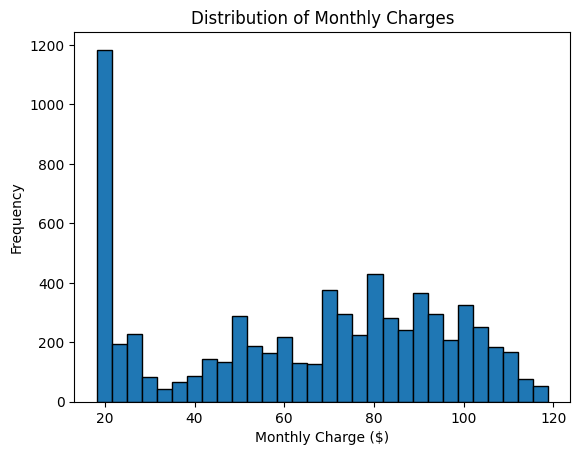

In [16]:
# Task 12 — numerical feature 2: distribution plot
df['MonthlyCharges'].plot(kind='hist', bins=30, title='Distribution of Monthly Charges', edgecolor='black')
plt.xlabel('Monthly Charge ($)')
plt.show()

**Observation:** _(A large portion of customers pay the minimum amount (around $20), which likely represents basic phone service without internet. The rest of the charges are spread out between $40 and $118)_

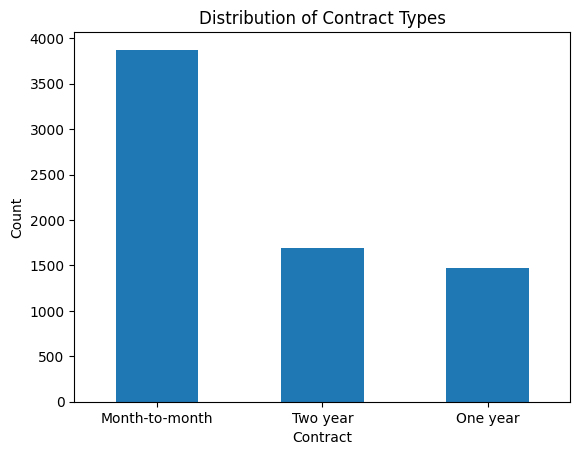

In [17]:
# Task 12 — categorical feature 1: distribution plot
df['Contract'].value_counts().plot(kind='bar', title='Distribution of Contract Types', rot=0)
plt.ylabel('Count')
plt.show()


**Observation:** _("Month-to-month" is by far the most common contract type, representing more than half of the entire customer base)_

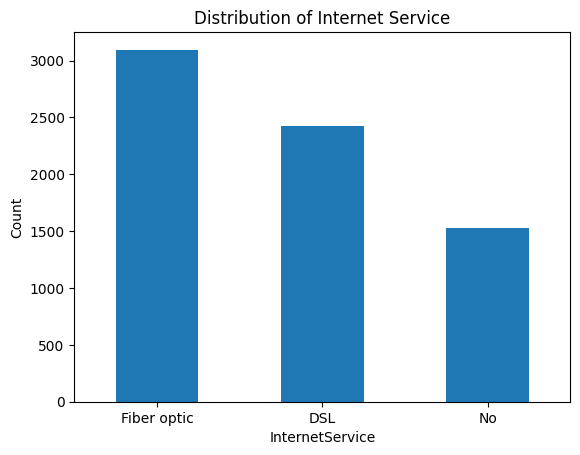

In [18]:
# Task 12 — categorical feature 2: distribution plot
df['InternetService'].value_counts().plot(kind='bar', title='Distribution of Internet Service', rot=0)
plt.ylabel('Count')
plt.show()


**Observation:** _(Fiber optic is the most popular internet service provided, followed by DSL. A smaller, but significant, group of customers do not have internet service at all.)_

**Answer 13 (outliers / skew and possible explanation):**
_(neither tenure nor MonthlyCharges show extreme outliers. Instead of being heavily skewed in one direction, they are bimodal. The clustering at the high and low ends of tenure is explained by the business model: many people try the service and leave quickly, but those who stay tend to remain locked in for years.)_

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

In [ ]:
# Task 14 — churn counts and percentages


**Answer 14 (balanced or imbalanced?):**
_(your answer here)_

**Answer 15 (why imbalance might matter later):**
_(your answer here)_

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

In [ ]:
# Task 16 — categorical feature 1 vs Churn


**Observation:** _..._
**Evidence:** _..._
**Possible Explanation:** _..._

In [ ]:
# Task 16 — categorical feature 2 vs Churn


**Observation:** _..._
**Evidence:** _..._
**Possible Explanation:** _..._

In [ ]:
# Task 17 — numerical feature 1 vs Churn


**Observation:** _..._
**Evidence:** _..._
**Possible Explanation:** _..._

In [ ]:
# Task 17 — numerical feature 2 vs Churn


**Observation:** _..._
**Evidence:** _..._
**Possible Explanation:** _..._

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

In [ ]:
# Task 18 — correlation matrix and heatmap


**Answer 18 (most correlated pairs):**
_(your answer here)_

**Answer 19 (correlation vs. causation; potential problems):**
_(your answer here)_

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**
_(your answer here)_

**Answer 21 (what would go wrong):**
_(your answer here)_

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | Remove | ... |
| tenure | Numerical | Feature | ... | ... |
| Contract | Categorical | Feature | ... | ... |
| Churn | Categorical | Target | Keep | ... |
| ... | ... | ... | ... | ... |

_(Add one row per remaining column — copy the pattern above.)_

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [ ]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

# ... apply your cleaning steps here ...

# Save the cleaned dataset
clean_df.to_csv("clean_churn.csv", index=False)


In [ ]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df


---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
- Observation: _..._
- Evidence: _..._
- Interpretation: _..._

**Finding 2**
- Observation: _..._
- Evidence: _..._
- Interpretation: _..._

**Finding 3**
- Observation: _..._
- Evidence: _..._
- Interpretation: _..._

**Finding 4**
- Observation: _..._
- Evidence: _..._
- Interpretation: _..._

**Finding 5**
- Observation: _..._
- Evidence: _..._
- Interpretation: _..._

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
   _(your answer here)_
2. What was the most interesting pattern you discovered?
   _(your answer here)_
3. Which feature seems most useful for predicting churn?
   _(your answer here)_
4. Which feature should probably not be used, and why?
   _(your answer here)_
5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?
   _(your answer here)_
6. What would you do next if you had another 3 hours?
   _(your answer here)_

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

In [ ]:
# Bonus — optional exploration


---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Completed all 26 tasks above, with written interpretation for every chart and decision
- [ ] A working `clean_df`, saved as `clean_churn.csv`
- [ ] A completed ML-readiness table (Part 10) covering every column
- [ ] Five Key Findings written (Part 12)
- [ ] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook